### Assignment 1 (4 scores):

- Use Numpy only to construct the Logistic Regression model.
- Train and evaluating (precision, recall, f1) the Logistic Regression model using the Gradient Descent approach **to classify 0 and 1 digit images** on the [MNIST](https://github.com/cvdfoundation/mnist?tab=readme-ov-file) dataset.
- Visualize the loss function of the training process.

In [188]:
from sklearn.datasets import fetch_openml
mnist = fetch_openml('mnist_784', version = 1, as_frame = False)
X, y = mnist['data'], mnist['target']
print(X.shape)

(70000, 784)


In [189]:
from sklearn.metrics import precision_score, recall_score, f1_score


In [190]:
y = y.astype(int)

In [191]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

In [192]:
mask_train = (y_train == 0 ) | (y_train == 1)
mask_test = (y_test == 0) | (y_test == 1)

In [193]:
X_train_filtered, y_train_filtered = X_train[mask_train], y_train[mask_train]
X_test_filtered, y_test_filtered = X_test[mask_test], y_test[mask_test]


In [194]:
X_train_filtered.shape

(11837, 784)

In [195]:
# Logistic Regression là bài toán dùng hàm sigmoid để phân lớp. Để xây dựng lại được class LogisticRegression thì cần mảng numpy (tham số theta để lưu trữ)
# code hàm fit, nhận data đầu vào trả về giá trị đầu ra , so sánh giá trị đầu ra với giá trị ground_truth, dùng gradient descent để giảm loss function
# Hàm loss function là hàm cập nhật lại mảng numpy phụ thuộc vào đạo hàm của Loss function lên tham số theta và learning_rate. 
# Cần một function tính toán đạo hàm 
# Đạo hàm của hàm sigmoid (f(x)) là f(x)(1 - f(x)) . Hàm này hoàn toàn không phù hợp với tối ưu hàm loss function
# Hàm loss function đáp ứng được yêu cầu là càng gần 1 thì loss function càng nhỏ, càng gần 0 thì loss function càng lớn -> sử dụng hàm log
# Một function sử dụng theta đã có để đưa ra kết quả đầu ra 

In [196]:
import numpy as np

In [197]:
# class LogisticRegression():
#     def __init__(self, learning_rate = 0.01, epochs = 1000):
#         self.lr = learning_rate
#         self.epochs = epochs
#         self.theta = None
#         self.bias = 0
    
#     def _sigmoid(self, z):
#         return 1/(1 + np.exp(-z))

#     def compute_loss(self, y_true, y_pred):
#         m = len(y_true)

#         epsilon = 1e-15
#         y_pred = np.clip(y_pred, epsilon, 1 - epsilon)
#         return -(1/m) * np.sum(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))
    
#     def fit(self, X, y):
#         m, n = X.shape
#         self.theta = np.zeros(n)
#         self.bias = 0

#         for _ in range(self.epochs):

#             model_result = np.dot(X, self.theta) + self.bias
#             y_pred = self._sigmoid(model_result)

#             dw = (1/m) * np.dot(X.T, (y_pred - y))
#             db = (1/m) * np.sum(y_pred - y)

#             self.theta -= self.lr * dw
#             self.bias -= self.lr * db
            

#     def predict(self, X):
#         model_result = np.dot(X, self.theta) + self.bias
#         y_pred = self._sigmoid(model_result)
#         return [1 if i > 0.5 else 0 for i in y_pred]
    

In [198]:
# Minh họa hàm loss function bằng biểu đồ minh họa loss theo epochs
# Class LogisticRegression hiện tại chưa có cơ chế lưu trữ loss theo epochs -> cần điều chỉnh lại code


In [199]:
class LogisticRegression():
    def __init__(self, learning_rate = 0.01, epochs = 100):
        self.lr = learning_rate
        self.epochs = epochs
        self.theta = None
        self.bias = 0
        # Khởi tạo danh sách để lưu loss
        self.loss_history = []
    
    def _sigmoid(self, z):
        return 1/(1 + np.exp(-z))

    def compute_loss(self, y_true, y_pred):
        m = len(y_true)

        epsilon = 1e-15
        y_pred = np.clip(y_pred, epsilon, 1 - epsilon)
        return -(1/m) * np.sum(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))
    
    def fit(self, X, y):
        m, n = X.shape
        self.theta = np.zeros(n)
        self.bias = 0
        # Reset lại lịch sử loss mỗi khi bắt đầu fit lại
        self.loss_history = []

        for _ in range(self.epochs):

            model_result = np.dot(X, self.theta) + self.bias
            y_pred = self._sigmoid(model_result)

            dw = (1/m) * np.dot(X.T, (y_pred - y))
            db = (1/m) * np.sum(y_pred - y)

            self.theta -= self.lr * dw
            self.bias -= self.lr * db
            loss = self.compute_loss(y, y_pred)
            self.loss_history.append(loss)
            
    def predict(self, X):
        model_result = np.dot(X, self.theta) + self.bias
        y_pred = self._sigmoid(model_result)
        return [1 if i > 0.5 else 0 for i in y_pred]
    

In [200]:
model = LogisticRegression()
model.fit(X_train_filtered, y_train_filtered)

D:\ml_cache\temp\ipykernel_18792\2559578411.py:11: RuntimeWarning: overflow encountered in exp
  return 1/(1 + np.exp(-z))


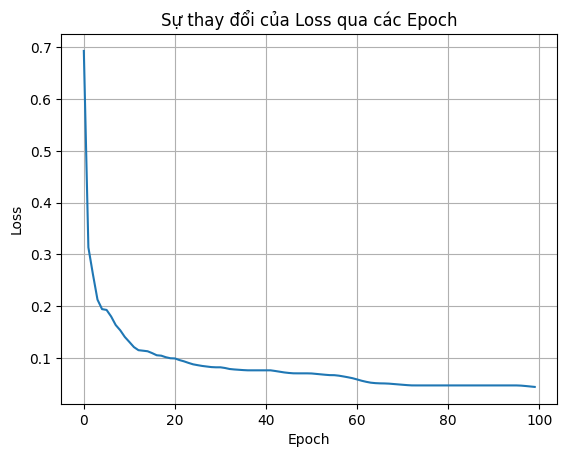

In [201]:
import matplotlib.pyplot as plt
plt.plot( model.loss_history)
plt.title('Sự thay đổi của Loss qua các Epoch')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)
plt.show()

In [202]:
y_pred = model.predict(X_test_filtered)

D:\ml_cache\temp\ipykernel_18792\2559578411.py:11: RuntimeWarning: overflow encountered in exp
  return 1/(1 + np.exp(-z))


In [203]:
print(np.array(y_pred).shape)

(2943,)


In [204]:
print(np.array(y_test_filtered).shape)

(2943,)


In [205]:
precision = precision_score(y_test_filtered, y_pred)
recall = recall_score(y_test_filtered, y_pred)
f1 = f1_score(y_test_filtered, y_pred)


In [206]:
print(precision)
print(recall)
print(f1)

0.9974953036944271
0.995625
0.9965592743196747


### Assignment 2 (4 scores):

- Use Numpy only to construct the Softmax Regression model.
- Train and evaluating (precision, recall, f1) the Softmax Regression model using the Gradient Descent approach **to classify 10 digit images** on the [MNIST](https://github.com/cvdfoundation/mnist?tab=readme-ov-file) dataset.
- Visualize the loss function of the training process.

In [207]:
X_copy = X.copy()
y_copy = y.copy()

mask = (y_copy >= 0 ) & (y_copy <=9 )

X_filtered = X_copy[mask]
y_filtered = y_copy[mask]

X_filtered = X_filtered/ 255 


In [208]:
X_train, X_test, y_train, y_test = train_test_split(X_filtered, y_filtered, test_size = 0.2, random_state = 42)

In [ ]:
# Hàm softmax khác với Logistic ở chỗ sử dụng hàm e mũ có thể phóng đại giá trị lớn, thu nhỏ giá trị nhỏ -> giúp mô hình tự tin hơn về lựa chọn của nó
# Hàm softmax được sử dụng bởi những lý do sau: 
# 1. Xử lý được số âm 
# 2. Giúp nới rộng khoảng cách giữa các giá trị. Ví du nếu có mảng 5 10 15. Thay vì mô hình khó chọn ra giá trị thì qua hàm softmax mô hinh sẽ tự tin vì mảng kết quả là: 0.004, 0.66, 99.33 
# 3. Đạo hàm của softmax khi kết hợp với Cross-Entropy là y - y' -> Rất dễ áp dụng Gradient Descent
import numpy as np

class SoftmaxRegression:
    def __init__(self, learning_rate=0.01, epochs=100):
        self.lr = learning_rate
        self.epochs = epochs
        self.weights = None 
        self.bias = None    
        self.epoch_history = [] 

    def _softmax(self, z):
        exp_z = np.exp(z - np.max(z, axis=1, keepdims=True))
        return exp_z / np.sum(exp_z, axis=1, keepdims=True)

    def _to_one_hot(self, y, num_classes):
        one_hot = np.zeros((y.size, num_classes))
        one_hot[np.arange(y.size), y] = 1
        return one_hot

    def compute_loss(self, y_true_oh, y_pred):
        m = y_true_oh.shape[0]
        epsilon = 1e-15
        y_pred = np.clip(y_pred, epsilon, 1 - epsilon)
        return - (1/m) * np.sum(y_true_oh * np.log(y_pred))

    def fit(self, X, y):
        m, n = X.shape
        num_classes = len(np.unique(y))
        
        self.weights = np.zeros((n, num_classes))
        self.bias = np.zeros((1, num_classes))
        self.epoch_history = []

        y_true_oh = self._to_one_hot(y, num_classes)

        for epoch in range(self.epochs):
            z = np.dot(X, self.weights) + self.bias
            y_pred = self._softmax(z)

            loss = self.compute_loss(y_true_oh, y_pred)
            self.epoch_history.append(loss)

            dw = (1/m) * np.dot(X.T, (y_pred - y_true_oh))
            db = (1/m) * np.sum(y_pred - y_true_oh, axis=0, keepdims=True)

            self.weights -= self.lr * dw
            self.bias -= self.lr * db

            if epoch % 100 == 0:
                print(f"Epoch {epoch}, Loss: {loss:.4f}")

    def predict(self, X):
        z = np.dot(X, self.weights) + self.bias
        y_pred = self._softmax(z)
        return np.argmax(y_pred, axis=1)

In [210]:
model = SoftmaxRegression()
model.fit(X_train, y_train)

Epoch 0, Loss: 2.3026


Epoch 0, Loss: 2.3026


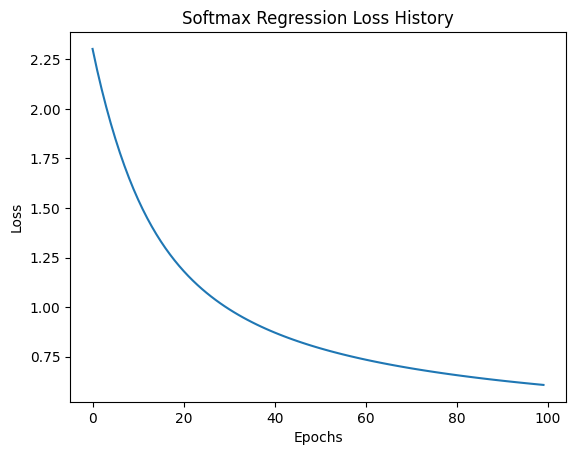

In [211]:
import matplotlib.pyplot as plt
model = SoftmaxRegression(learning_rate = 0.1, epochs = 100)
model.fit(X_train, y_train)

plt.plot(model.epoch_history)
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title("Softmax Regression Loss History")
plt.show()


In [212]:
y_pred = model.predict(X_test)
precision = precision_score(y_test, y_pred, average = 'macro')
recall = recall_score(y_test, y_pred, average = 'macro')
f1 = f1_score(y_test, y_pred, average = 'macro')

print(precision)
print(recall)
print(f1)

0.861567019616875
0.8590159464120168
0.8592261780701118


### Assignment 3 (2 scores):

- Use a Machine Learning library (Scikit Learn or Skorch) to implement and evaluate the Logistic Regression on the [MNIST](https://github.com/cvdfoundation/mnist?tab=readme-ov-file) dataset.
- Use a Machine Learning library (Scikit Learn or Skorch) to implement and evaluate the Softmax Regression on the [MNIST](https://github.com/cvdfoundation/mnist?tab=readme-ov-file) dataset.

In [213]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

X_train_bin = X_train_filtered / 255.0
X_test_bin = X_test_filtered / 255.0

log_reg_bin = LogisticRegression(solver='liblinear', random_state=42)
log_reg_bin.fit(X_train_bin, y_train_filtered)

y_pred_bin = log_reg_bin.predict(X_test_bin)

print(classification_report(y_test_filtered, y_pred_bin))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1343
           1       1.00      1.00      1.00      1600

    accuracy                           1.00      2943
   macro avg       1.00      1.00      1.00      2943
weighted avg       1.00      1.00      1.00      2943



In [214]:
X_train_all, X_test_all, y_train_all, y_test_all = train_test_split(
    X, y, test_size=0.2, random_state=42
)

X_train_all = X_train_all / 255.0
X_test_all = X_test_all / 255.0

softmax_reg = LogisticRegression(
    multi_class='multinomial', 
    solver='lbfgs', 
    max_iter=1000, 
    random_state=42
)
softmax_reg.fit(X_train_all, y_train_all)

y_pred_all = softmax_reg.predict(X_test_all)

print(classification_report(y_test_all, y_pred_all))

c:\Users\hi\miniconda3\envs\phan_tich_thuc_nghiem\lib\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


              precision    recall  f1-score   support

           0       0.96      0.97      0.96      1343
           1       0.94      0.97      0.96      1600
           2       0.91      0.89      0.90      1380
           3       0.90      0.89      0.90      1433
           4       0.92      0.93      0.93      1295
           5       0.88      0.88      0.88      1273
           6       0.94      0.95      0.95      1396
           7       0.93      0.94      0.93      1503
           8       0.90      0.87      0.88      1357
           9       0.90      0.90      0.90      1420

    accuracy                           0.92     14000
   macro avg       0.92      0.92      0.92     14000
weighted avg       0.92      0.92      0.92     14000

